In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


# 2. Load Dataset

In [2]:
df=pd.read_csv("/kaggle/input/datasets/ramsaitirumanadham/movie-ratings/IMDb Movies India.csv",encoding='latin')

# 3. Data Exploration


In [3]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [5]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [6]:
df.tail()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN
15508,Zulm-O-Sitam,(1998),130 min,"Action, Drama",6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [7]:
df.shape

(15509, 10)

# 4. Handle missing values

In [8]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [9]:
df=df.dropna(subset=['Rating'])

# 5. Clean Year,Duration,Votes

In [10]:
df['Year']
df['Year'].astype(str).str.extract(r'(\d{4})',expand=False)
df['Year']=pd.to_numeric(df['Year'],errors='coerce')

In [11]:
df['Duration']
df['Duration'].astype(str).str.extract(r'(\d+)',expand=False)
df['Duration']=pd.to_numeric(df['Duration'],errors='coerce')

In [12]:
df['Votes']=df['Votes'].astype(str).str.replace(',','')
df['Votes']=pd.to_numeric(df['Votes'],errors='coerce')

# 6. Fill Missing Values

In [13]:
df.fillna({
    'Year':df['Year'].median(),'Duration':df['Duration'].median(),'Votes':df['Votes'].median()
},inplace=True)

In [14]:
text_cols=['Genre','Director','Actor 1','Actor 2','Actor 3','Name']
for col in text_cols:
    df[col]=df[col].fillna("Unknown")

# 7. Data Visualization

* **Rating Distribution**

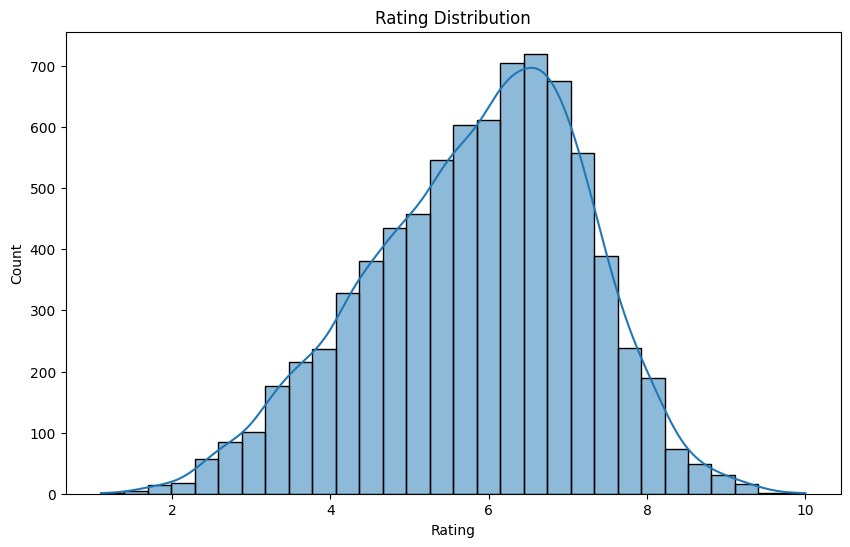

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['Rating'],bins=30,kde=True)
plt.title("Rating Distribution")
plt.show()

* **Top Genres**

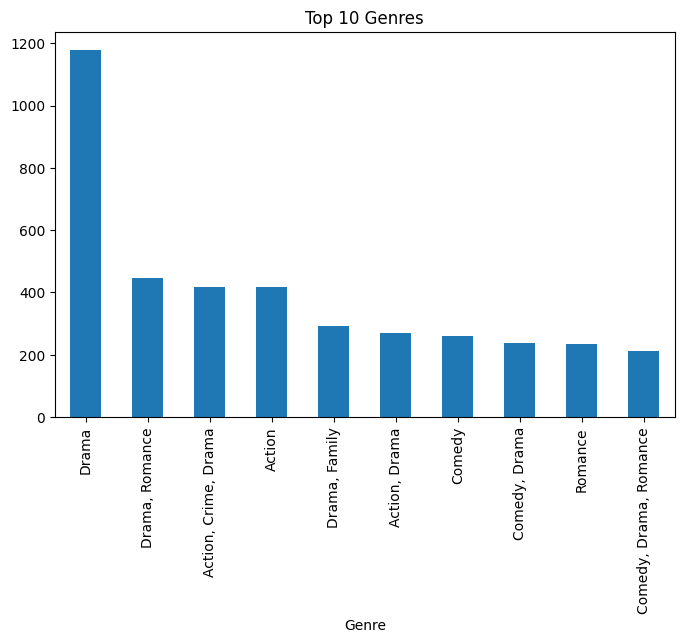

In [16]:
plt.figure(figsize=(8,5))
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.show()

* **Rating vs Votes**

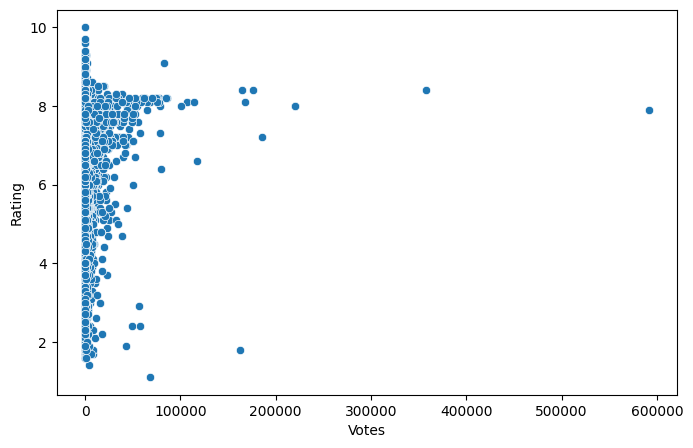

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Votes',y='Rating',data=df)
plt.show()

* **Correlation Heatmap**

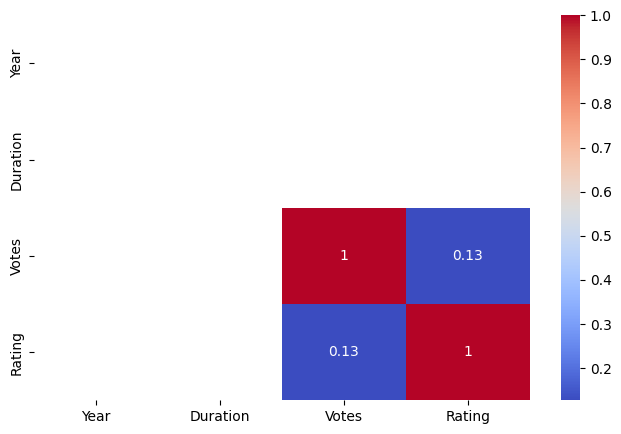

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Year','Duration','Votes','Rating']].corr(),annot=True,cmap='coolwarm')
plt.show()

# 8. Feature Selection & Encoding

In [19]:
X=df[['Genre','Director','Actor 1','Actor 2','Actor 3','Year','Duration','Votes','Name']].copy()
y=df['Rating']

In [20]:
le=LabelEncoder()
for col in X.columns:
    if X[col].dtype=='object':
        X[col]=le.fit_transform(X[col].astype(str))

# 9. Train-test Split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                              test_size=0.2,
                                              random_state=42)

# 10. Train The Model

In [22]:
model=RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

# 11. Make Predictions

In [23]:
y_pred=model.predict(X_test)

# 12. Evaluation

* MAE
* RMSE
* R² Score


In [24]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 0.9690214646464645


In [25]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:",rmse)

RMSE: 1.2303712087445475


In [26]:
r2=r2_score(y_test,y_pred)
print("R² Score:",r2)

R² Score: 0.1857476437884067


# 13. Feature Importance

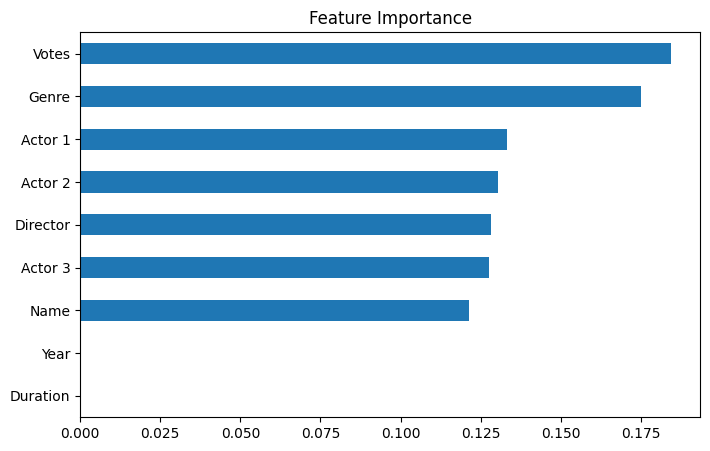

In [27]:
importance =pd.Series(
    model.feature_importances_,index=X.columns
)
importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title("Feature Importance")
plt.show()

# 14. Evaluation Metric Values

In [28]:
print("Model Performance")
print("----------------")
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))

Model Performance
----------------
MAE: 0.9690214646464645
RMSE: 1.2303712087445475
R2 Score: 0.1857476437884067


# 15. Actual vs Predicted values

In [29]:
results=pd.DataFrame({
    'Actual Rating':y_test.values,
    'Predicted Rating':y_pred
})
results.head(10)

,Actual Rating,Predicted Rating
0,3.3,4.864667
1,5.3,5.561333
2,5.7,4.633667
3,7.2,6.389667
4,3.5,4.186000
5,7.2,6.312333
6,3.8,5.920333
7,6.9,6.854333
8,5.2,6.169000
9,7.4,5.681333
